# The Benchmark Problem: Physics, Discretization and Reference Solutions

*One heterogeneous, nonlinear rod is studied throughout Parts II and III. This chapter defines it once: the governing equations, the finite-element discretization, how the reference ("ground-truth") solutions are computed and verified, the datasets and splits, the out-of-distribution test sets, and the error metrics. Every later chapter builds on these definitions.*

---

## 1. Why a common benchmark

The neural operators in this book are compared across chapters — different losses, architectures, and training strategies. Such comparisons are only meaningful if every model sees the same physics, the same inputs, the same data splits, and is graded against the same reference. All of this is implemented once, in a single module, `fem_ground_truth.py`, which every chapter of Parts II and III imports. The previous chapter used a simpler rod with constant $k_0$ because it admits a closed-form solution; from here on the material varies in space, and reference solutions must come from a numerical solver.

## 2. Governing equations

Transient heat conduction in a rod $x\in[0,1]$ with temperature- and position-dependent conductivity:

$$\rho c_p\,\frac{\partial T}{\partial t} = \frac{\partial}{\partial x}\left(k(x,T)\,\frac{\partial T}{\partial x}\right),\qquad k(x,T)=\alpha(x)\,\bigl(0.5+T^{2}\bigr),$$

$$T(0,t)=1,\qquad T(1,t)=0,\qquad T(x,0)=T_0(x),\qquad \rho c_p = 5 .$$

The factor $0.5+T^2$ makes the problem **nonlinear** (hotter regions conduct more), and the material field $\alpha(x)>0$ makes it **heterogeneous**. Because $k>0$, the solution relaxes to a unique **steady state** that depends on $\alpha$ only, not on $T_0$:

$$\frac{d}{dx}\left(k(x,T)\,\frac{dT}{dx}\right)=0,\qquad T(0)=1,\ T(1)=0 .$$

Part II learns the steady map $\alpha \mapsto T$; Part III learns the transient evolution $(T^n,\alpha)\mapsto T^{n+1}$ (or its time derivative).

## 3. Finite-element discretization

The rod is divided into $N-1$ linear elements of size $h=1/(N-1)$ with nodes $x_i$. With nodal conductivities $k_i = \alpha_i\,(0.5+T_i^2)$ and the element average $\bar k_e=\tfrac12(k_i+k_{i+1})$, the element mass and stiffness matrices are

$$M_e = \frac{\rho c_p\,h}{6}\begin{pmatrix}2&1\\1&2\end{pmatrix},\qquad K_e(T)=\frac{\bar k_e}{h}\begin{pmatrix}1&-1\\-1&1\end{pmatrix},$$

assembled into global $M$ (constant) and $K(T)$ (temperature-dependent). The semi-discrete system is

$$M\,\dot T + K(T)\,T = 0 ,$$

restricted to the interior ("free") nodes; the two boundary values are imposed exactly.

## 4. Time integration and nonlinear solution

**Transient.** Time is advanced with the **fully-implicit backward-Euler** scheme, with the conductivity evaluated at the *unknown* new state:

$$R(T^{n+1}) = \bigl(M+\Delta t\,K(T^{n+1})\bigr)\,T^{n+1} - M\,T^{n} = 0 .$$

Each step is a nonlinear system, solved with **Newton–Raphson**, $T \leftarrow T - J^{-1}R(T)$, using the exact Jacobian $J=\partial R/\partial T$ obtained by automatic differentiation (`jax.jacfwd`), starting from $T^n$ (4 iterations). Backward Euler is unconditionally stable, so the reference solver has no time-step restriction.

**Steady.** The steady residual $K(T)\,T = 0$ is solved with the same Newton–Raphson method from the linear ramp $T=1-x$ (25 iterations). Its implementation evaluates $K(T)\,T$ element by element (identical to the assembled matrix to $10^{-14}$) so that the exact Jacobian stays cheap on fine meshes.

## 5. Input fields: materials and initial conditions

The inputs are drawn from a fixed pool of **1000** pairs $(\alpha, T_0)$, generated once (seeds 42 / 7) on a 256-node grid and shared by every chapter. Both fields are built from a smooth random signal $s(x)\in[-1,1]$ taken from a mixture of three generators, following Yamazaki et al. (2025, *Eng. with Computers* 41, Sect. 3.3):

| Generator | Share | Construction |
| :--- | :--- | :--- |
| Fourier series | 40% | sum of 6 sinusoids with random offset, frequency, phase and $1/f^{0.8}$ amplitude decay |
| Gaussian random process | 50% | squared-exponential kernel, random length scale $\in[0.05,0.4]$ |
| Constant field | 10% | a single random value |

Each signal is min–max normalized and mapped to

$$\alpha(x) = 0.1 + 0.4\,\sigma\bigl(s_\alpha(x)\bigr)\in[0.21,\,0.39], \qquad T_0(x) = (1-x) + \sin(\pi x)\,s_T(x),$$

where $\sigma$ is the logistic function. The $\sin(\pi x)$ mask makes every $T_0$ satisfy the boundary conditions exactly. The figure below shows examples from each generator.

field pool: 1000 samples on 256 nodes; Fourier series: 391, Gaussian random process: 496, Constant field: 113


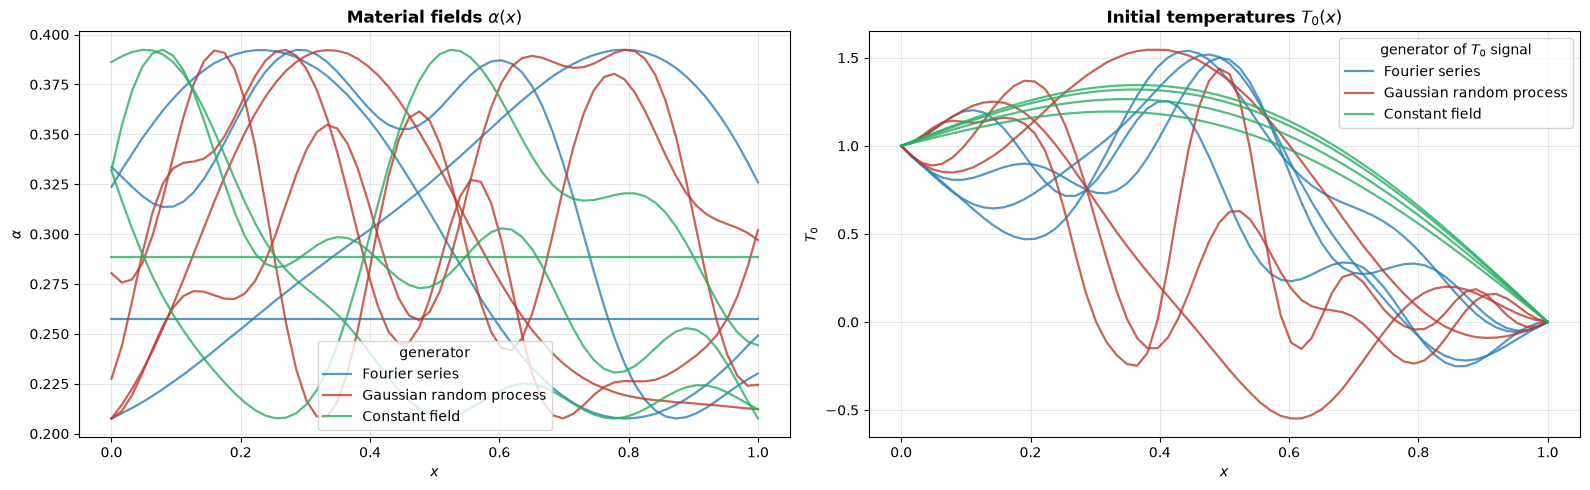

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import fem_ground_truth as fg

N = 64                                              # training resolution used in every chapter
GRID = np.linspace(0, 1, N)
pool = fg.load_field_pool("checkpoints/field_pool.npz")
alpha64 = np.asarray(fg.resample_field(jnp.asarray(pool["alpha"]), N))
T0_64 = np.asarray(fg.resample_field(jnp.asarray(pool["T0"]), N))
gen = np.asarray(pool["generator"])
print(f"field pool: {pool['T0'].shape[0]} samples on {int(pool['reference_n_nodes'])} nodes; "
      + ", ".join(f"{name}: {(gen == g).sum()}" for g, name in enumerate(fg.T0_GENERATOR_NAMES)))

colors = ["#2980b9", "#c0392b", "#27ae60"]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
rng = np.random.default_rng(0)
for g, (name, c) in enumerate(zip(fg.T0_GENERATOR_NAMES, colors)):
    for j, i in enumerate(rng.choice(np.where(gen == g)[0], size=4, replace=False)):
        axes[0].plot(GRID, alpha64[i], color=c, alpha=0.8, lw=1.6, label=name if j == 0 else None)
        axes[1].plot(GRID, T0_64[i], color=c, alpha=0.8, lw=1.6, label=name if j == 0 else None)
axes[0].set_title(r"Material fields $\alpha(x)$", fontweight="bold"); axes[0].set_ylabel(r"$\alpha$")
axes[1].set_title(r"Initial temperatures $T_0(x)$", fontweight="bold"); axes[1].set_ylabel(r"$T_0$")
for ax in axes:
    ax.set_xlabel("$x$"); ax.grid(True, alpha=0.3); ax.legend(title="generator of $T_0$ signal" if ax is axes[1] else "generator")
plt.tight_layout(); plt.show()

*Figure 1. Four samples per generator. Colours label the generator of the $T_0$ signal (for $\alpha$ the colour is that of the same sample's $T_0$; the two fields use independent draws). All $T_0$ satisfy $T_0(0)=1$, $T_0(1)=0$.*

## 6. Reference solutions: solve once, fine, then derive

A model trained at $N=64$ must not be graded against an $N=64$ FEM solve, because that solve carries its own discretization error and the comparison would mix the two. Instead each reference is solved **once on a much finer mesh, in double precision**, cached, and **derived** at any coarser $(N,\Delta t)$ without re-solving — by linear interpolation in space and exact stride sub-sampling in time (the target $\Delta t$ must be an integer multiple of the reference $\Delta t$, so no time interpolation is ever needed).

| Reference | Inputs | Fine mesh | Time | Used by |
| :--- | :--- | :--- | :--- | :--- |
| Transient, in-distribution | 1000 pool samples $(T_0,\alpha)$ | $N=256$ | $\Delta t=0.001$, $t\in[0,0.4]$ | Part III |
| Transient, OOD | 50 unseen $T_0$ shapes, $\alpha=0.25$ | $N=512$ | $\Delta t=0.001$, $t\in[0,0.4]$ | Part III |
| Steady, in-distribution | the same 1000 $\alpha$ fields | $N=511$ | — | Part II |
| Steady, OOD | 50 unseen $\alpha$ shapes | $N=511$ | — | Part II |

The steady mesh $N=511=2\cdot255+1$ contains every node of the pool's 256-node grid, so $\alpha$ is represented exactly. The steady reference was verified when it was built: Newton converges to a residual below $10^{-12}$ (25 and 40 iterations agree to $10^{-15}$), and re-solving at $N=256$ changes the in-distribution solutions by at most $10^{-5}$.

The figure shows one test sample through both references: its transient evolution and the steady state it approaches.

transient reference: (1000, 401, 256) (samples, time levels, nodes), dt=0.001, dtype=float64
steady reference:    (1000, 511), max |residual| = 2.3e-13, dtype=float64


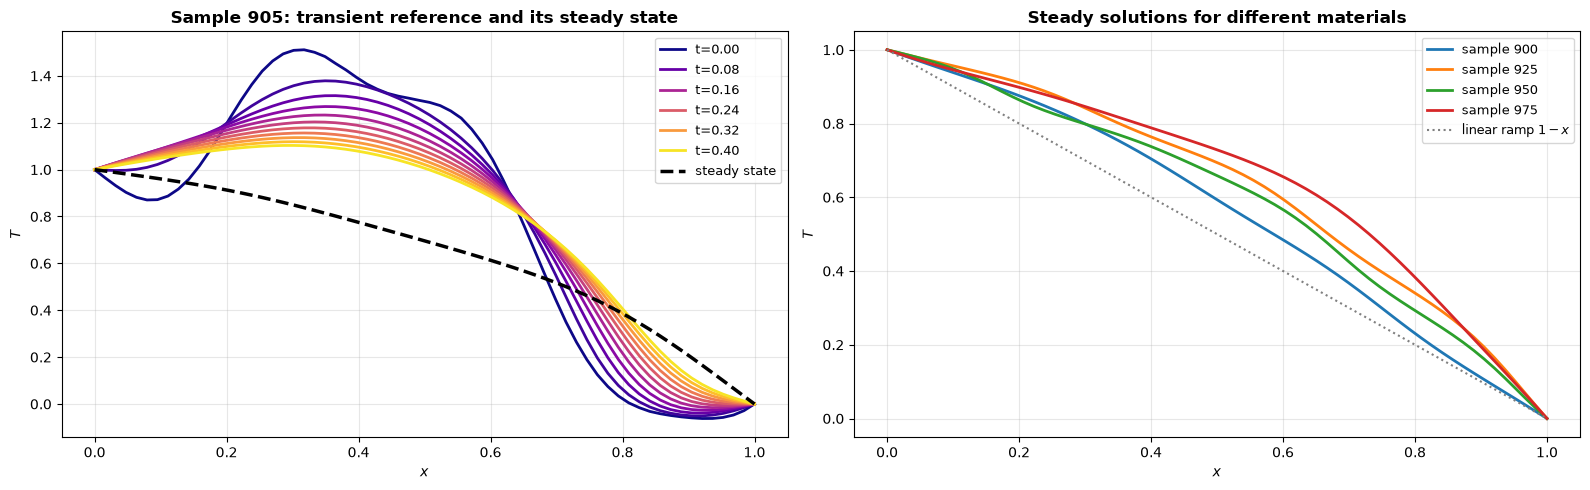

In [2]:
ref_tr = fg.load_dataset("checkpoints/fine_reference.npz")
ref_st = fg.load_dataset("checkpoints/steady_reference.npz")
print(f"transient reference: {ref_tr['trajectory'].shape} (samples, time levels, nodes), "
      f"dt={float(ref_tr['dt'])}, dtype={ref_tr['trajectory'].dtype}")
print(f"steady reference:    {ref_st['T'].shape}, max |residual| = {float(ref_st['max_residual']):.1e}, dtype={ref_st['T'].dtype}")

tr64 = fg.derive_dataset(ref_tr, n_nodes_target=N, dt_target=0.02)      # (1000, 21, 64): t = 0, 0.02, ..., 0.4
st64 = fg.derive_steady_dataset(ref_st, N)

i = 905
cmap = plt.get_cmap("plasma")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
for n in range(0, 21, 2):
    ax1.plot(GRID, tr64["trajectory"][i, n], color=cmap(n / 21), lw=2, label=f"t={0.02*n:.2f}" if n % 4 == 0 else None)
ax1.plot(GRID, st64["T"][i], "k--", lw=2.5, label="steady state")
ax1.set_title(f"Sample {i}: transient reference and its steady state", fontweight="bold")
ax1.set_xlabel("$x$"); ax1.set_ylabel("$T$"); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
for j in [900, 925, 950, 975]:
    ax2.plot(GRID, st64["T"][j], lw=2, label=f"sample {j}")
ax2.plot(GRID, 1 - GRID, ":", color="gray", label="linear ramp $1-x$")
ax2.set_title("Steady solutions for different materials", fontweight="bold")
ax2.set_xlabel("$x$"); ax2.set_ylabel("$T$"); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

*Figure 2. Left: the transient reference for one held-out sample over the horizon used in Part III ($t\le0.4$); the dashed curve is the steady state the same rod eventually reaches. Right: steady solutions for four materials. The deviation from the linear ramp is entirely due to the nonlinear, heterogeneous conductivity.*

## 7. The discretization floor at the training grid

Because models are graded against the fine reference, even a *perfect* operator working on the $N=64$, $\Delta t=0.02$ grid would not have zero error: an exact FEM solve on that coarse grid already differs from the fine reference. This **discretization floor** is the smallest error any model in Part III can meaningfully be expected to reach. It is measured below by solving the 100 held-out samples directly with FEM at $N=64$, $\Delta t=0.02$ and comparing with the derived reference.

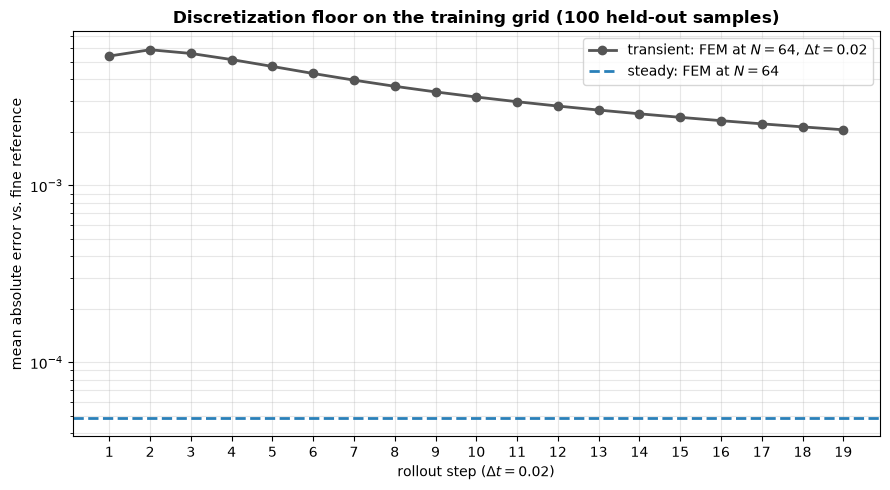

transient floor: step 1 = 5.39e-03, step 19 = 2.06e-03;  steady floor = 4.84e-05


In [3]:
TEST = slice(900, 1000)
T0_test = jnp.asarray(tr64["T0"][TEST]); A_test = jnp.asarray(tr64["alpha"][TEST])
coarse = fg.batch_fem_rollout(T0_test, A_test, 19, 0.02)                  # direct FEM at N=64, dt=0.02
floor = np.asarray(jnp.mean(jnp.abs(coarse - jnp.asarray(tr64["trajectory"][TEST, :20])), axis=(0, 2)))

steady_floor = float(np.mean(np.abs(np.asarray(jax.vmap(fg.solve_steady_fem)(jnp.asarray(st64["alpha"][TEST]))) - st64["T"][TEST])))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.arange(1, 20), floor[1:], "o-", color="#555555", lw=2, label="transient: FEM at $N=64$, $\\Delta t=0.02$")
ax.axhline(steady_floor, color="#2980b9", ls="--", lw=2, label="steady: FEM at $N=64$")
ax.set_yscale("log"); ax.set_xticks(range(1, 20))
ax.set_xlabel("rollout step ($\\Delta t = 0.02$)"); ax.set_ylabel("mean absolute error vs. fine reference")
ax.set_title("Discretization floor on the training grid (100 held-out samples)", fontweight="bold")
ax.grid(True, which="both", alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()
print(f"transient floor: step 1 = {floor[1]:.2e}, step 19 = {floor[-1]:.2e};  steady floor = {steady_floor:.2e}")

*Figure 3. Error of an exact FEM solve on the training grid, measured against the fine reference. In the transient case it is dominated by the coarse time step; in the steady case only the spatial error remains and it is far smaller.*

This sets the scale for reading every later error plot: transient operator errors near this curve are as good as the grid allows, and errors well above it come from the model itself.

## 8. Datasets and splits

The 1000 pool samples are split identically in every chapter:

| Samples | Role |
| :--- | :--- |
| 0 – 799 | training |
| 800 – 899 | validation (early stopping, where used) |
| 900 – 999 | held-out test — never seen by training or model selection |

Part III uses a rollout horizon of 19 steps of $\Delta t=0.02$ ($t=0\ldots0.38$). The label-free transient operators (weighted residual, PITI) train on the initial states $T_0$ only, so every rollout step after the first is extrapolation for them.

## 9. Out-of-distribution test sets

Generalization is tested along two axes at once. **Shape:** 50 fields from families that never occur in training, split 13 / 13 / 12 / 12. **Resolution:** each is evaluated on the training grid $N=64$ and on $N=96,128,160,192,256$ (super-resolution), i.e. 300 evaluations per model. The transient set varies the initial temperature at fixed $\alpha=0.25$; the steady set varies the material within the training range of $\alpha$, so it is novel in shape, not in magnitude.

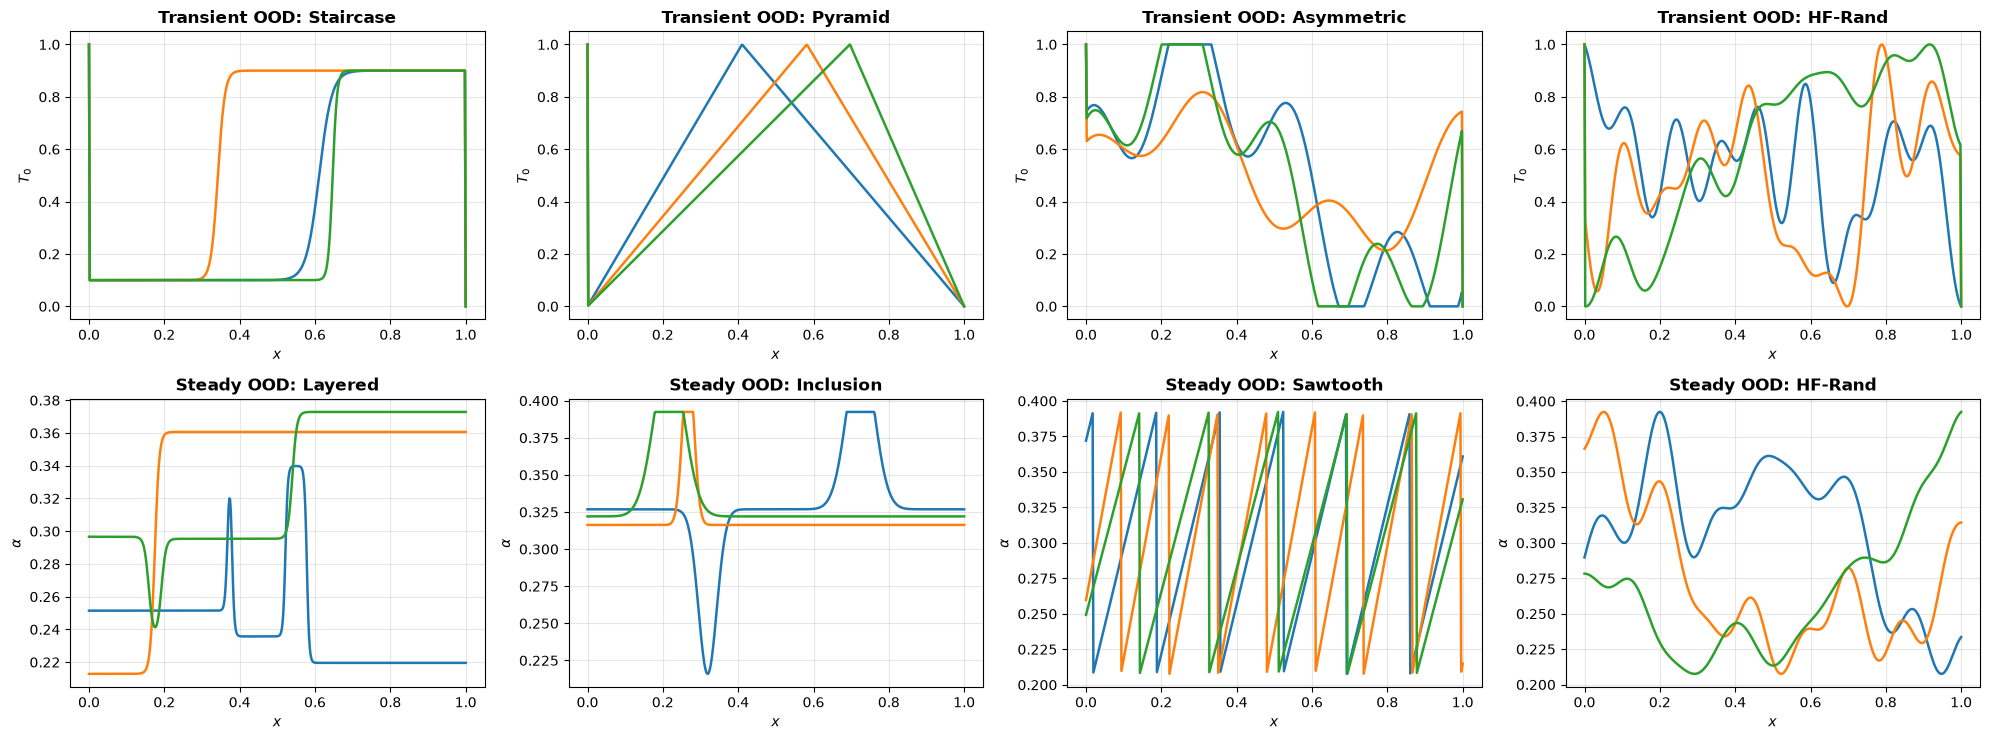

In [4]:
ood_tr = fg.load_ood_fine_trajectories("checkpoints/ood_fine_reference.pkl")
fam_tr = ["Staircase", "Pyramid", "Asymmetric", "HF-Rand"]
xs_tr = np.linspace(0, 1, ood_tr["T0"].shape[1]); xs_st = np.linspace(0, 1, ref_st["ood_alpha"].shape[1])
fig, axes = plt.subplots(2, 4, figsize=(20, 7.5))
for k, fam in enumerate(fam_tr):
    idx = [i for i, f in enumerate(ood_tr["families"]) if f == fam][:3]
    for i in idx:
        axes[0, k].plot(xs_tr, ood_tr["T0"][i], lw=1.8)
    axes[0, k].set_title(f"Transient OOD: {fam}", fontweight="bold"); axes[0, k].set_ylabel("$T_0$")
for k, fam in enumerate(fg.STEADY_OOD_FAMILIES):
    idx = np.where(ref_st["ood_families"] == fam)[0][:3]
    for i in idx:
        axes[1, k].plot(xs_st, ref_st["ood_alpha"][i], lw=1.8)
    axes[1, k].set_title(f"Steady OOD: {fam}", fontweight="bold"); axes[1, k].set_ylabel(r"$\alpha$")
for ax in axes.ravel():
    ax.set_xlabel("$x$"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

*Figure 4. Three examples of each out-of-distribution family. Top: transient initial temperatures (smoothed step, off-centre pyramid, two-harmonic mix, high-frequency random). Bottom: steady materials (layered composite with sharp interfaces, narrow inclusions, sawtooth, high-frequency random).*

## 10. Error metrics and notation

**Mean absolute error per rollout step** (Part III), averaged over the $N_s$ evaluated samples and the $N$ nodes:

$$\text{MAE}(n) = \frac{1}{N_s\,N}\sum_{s=1}^{N_s}\sum_{j=1}^{N}\bigl|T^{n}_{\text{ref},s,j}-T^{n}_{\text{pred},s,j}\bigr| .$$

**Relative $L^2$ error** (Part II), per sample and then averaged:

$$e_{L^2} = \frac{\lVert T_{\text{pred}}-T_{\text{ref}}\rVert_2}{\lVert T_{\text{ref}}\rVert_2}.$$

| Symbol | Meaning |
| :--- | :--- |
| $\alpha(x)$ | material field (network input) |
| $T_0(x)$, $T^n$ | initial temperature; temperature at step $n$ |
| $M$, $K(T)$ | FEM mass and stiffness matrices |
| $\Delta t$, $N$ | time step; number of grid nodes |
| $\dot T$, $\tilde T_t$ | time derivative; its network prediction |
| sg$(\cdot)$ | stop-gradient |

## 11. Roadmap

| Chapter | Question | Answer (see the chapter) |
| :--- | :--- | :--- |
| [Steady-state FNO](FNO_STEADY_STATE.ipynb) | Can an FNO learn $\alpha\mapsto T$ from FEM data? | Yes, including on unseen shapes and finer grids |
| [Loss comparison](FNO_loss_comparison.ipynb) | Which training objective? | The label-free weighted residual |
| [Architecture comparison](architecture_comparison.ipynb) | Which operator architecture? | The FNO: best out-of-distribution per unit cost |
| [Data-driven transient FNO](FNO_transient_data_driven.ipynb) | Can the FNO step the transient problem from labels? | Yes; baseline for Part III |
| [Weighted-residual transient FNO](FNO_transient_weighted_residual.ipynb) | ...without any labels, from $T_0$ only? | Yes, and it generalizes best |
| [PITI-FNO](FNO_transient_PITI.ipynb) | Can the time step be decoupled from training? | Yes, within stability limits, at an accuracy cost |
| [Transient comparison](transient_comparison.ipynb) | How do the three compare? | Side-by-side on the same reference |
| [Summary and outlook](conclusions.md) | What was learned, what is open? | — |